# 04. Диагностика остатков базовой модели

**Цель**: проверить выполнение всех предпосылок OLS (конспект §3) для лучшей базовой модели — **Min** (из блока 3).

**Предпосылки** (конспект §1.1):
1. `E[ε_i] = 0`
2. `ε_i ~ N(0, σ²)` — нормальность
3. `D[ε_i] = σ² = const` — гомоскедастичность
4. `Cov(ε_i, ε_j) = 0` — нет автокорреляции
5. Линейность формы
6. Нет мультиколлинеарности (проверено в блоке 3)


In [1]:
import sys, pathlib, json as _json, pickle
sys.path.insert(0, str(pathlib.Path('.').resolve()))
from helpers import (set_plot_style, load_data, impute_median, make_design,
                     backward_elimination, format_test_row, white_test,
                     NUM_COLS_FULL, CAT_FEATURES)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import (het_breuschpagan, het_white,
                                            het_goldfeldquandt, linear_reset)
from statsmodels.stats.stattools import durbin_watson

set_plot_style()
df, df_train, df_test = load_data()
df_train = impute_median(df_train, NUM_COLS_FULL)
with open('selected_features.json') as fh:
    KEEP = _json.load(fh)['keep']

X_best, _ = make_design(df_train, KEEP, CAT_FEATURES)
X_best_c = sm.add_constant(X_best.astype(float))
y = df_train['price_log1p'].values
m_min, X_min_c, _ = backward_elimination(X_best_c, y)
print(f'Min model: R²adj={m_min.rsquared_adj:.4f}  k={len(m_min.params)}')


Min model: R²adj=0.7969  k=30


## 1. Стандартизованные остатки (конспект §3.1)

$$u_i = \frac{y_i - \hat{y}_i}{\hat{\sigma}\sqrt{1 - p_{ii}}}$$

где `p_ii` — диагональ hat-матрицы. Деление на `√(1−p_ii)` компенсирует разную нагрузку наблюдений.


In [2]:
influence = m_min.get_influence()
std_resid = pd.Series(influence.resid_studentized_internal)
std_resid = std_resid.replace([np.inf, -np.inf], np.nan).dropna().values
raw_resid = m_min.resid.values
fitted    = m_min.fittedvalues.values

print(f'Сырые остатки:        mean={raw_resid.mean():.3e}  std={raw_resid.std():.4f}')
print(f'Стандартизованные:    mean={std_resid.mean():.3e}  std={std_resid.std():.4f}')


Сырые остатки:        mean=-8.544e-14  std=0.5231
Стандартизованные:    mean=7.116e-05  std=1.0008


## 2. Проверка нормальности остатков (конспект §3.2)

**H₀**: остатки имеют нормальное распределение, `ε ~ N(0, σ²)`.
**H₁**: распределение отличается от нормального.


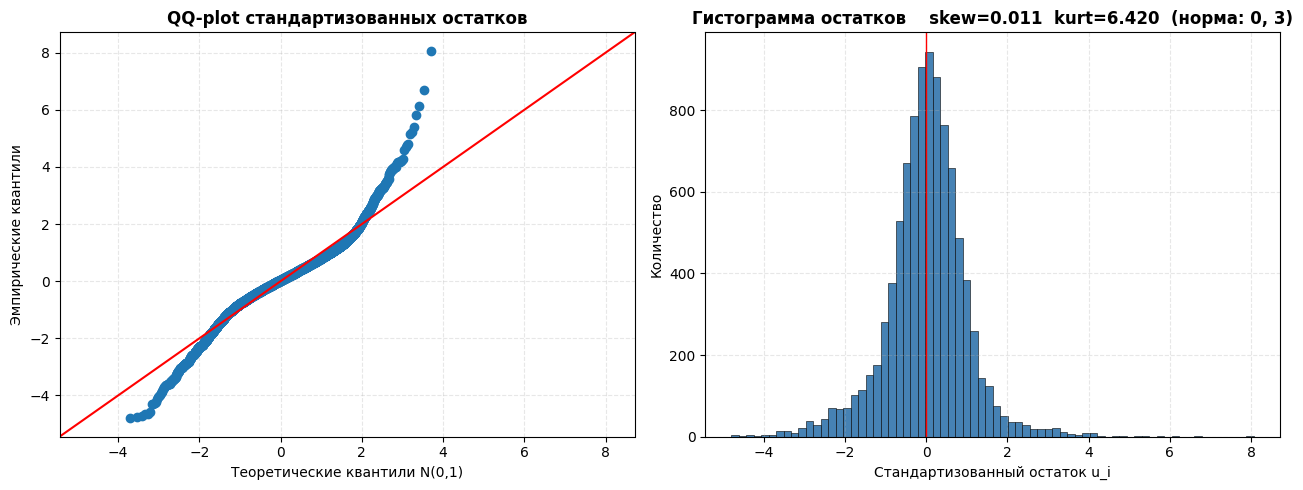

In [3]:
# Графика: QQ-plot + гистограмма с skew/kurt
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sm.qqplot(std_resid, line='45', fit=False, ax=axes[0])
axes[0].set_title('QQ-plot стандартизованных остатков')
axes[0].set_xlabel('Теоретические квантили N(0,1)')
axes[0].set_ylabel('Эмпирические квантили')

sk = stats.skew(std_resid)
kt = stats.kurtosis(std_resid, fisher=False)
axes[1].hist(std_resid, bins=70, color='steelblue', edgecolor='black', linewidth=0.4)
axes[1].set_title(f'Гистограмма остатков    skew={sk:.3f}  kurt={kt:.3f}  (норма: 0, 3)')
axes[1].set_xlabel('Стандартизованный остаток u_i')
axes[1].set_ylabel('Количество')
axes[1].axvline(0, color='red', lw=1)
plt.tight_layout(); plt.show()


In [4]:
# Тесты нормальности
jb_stat, jb_pval = stats.jarque_bera(std_resid)
# Шапиро на подвыборке (тест ограничен 5000)
sample = std_resid if len(std_resid) <= 5000 else \
         np.random.RandomState(0).choice(std_resid, 5000, replace=False)
sh_stat, sh_pval = stats.shapiro(sample)

tests_normality = pd.DataFrame([
    format_test_row('Jarque–Bera',  'ε ~ N(0,σ²)', 'JB', jb_stat, jb_pval),
    format_test_row(f'Shapiro–Wilk (n={len(sample)})',
                    'ε ~ N(0,σ²)', 'W', sh_stat, sh_pval),
])
tests_normality


,тест,H₀,JB,p-value,α=0.05,W
0,Jarque–Bera,"ε ~ N(0,σ²)",4621.5746,0,отвергаем H₀,NaN
1,Shapiro–Wilk (n=5000),"ε ~ N(0,σ²)",NaN,1.29e-37,отвергаем H₀,0.9521


**Интерпретация**: при `n=9.5k` тесты JB и Shapiro–Wilk **почти всегда отвергают** H₀ — они слишком чувствительны для больших выборок. Смотрим на skew/kurt: если они близки к (0, 3), форма распределения «практически нормальна» (CLT работает для коэффициентов).


## 3. Графики остатков (конспект §3.3)

Ищем структуру (воронку, кривизну) в графиках `e vs ŷ` и `e vs x_j`.


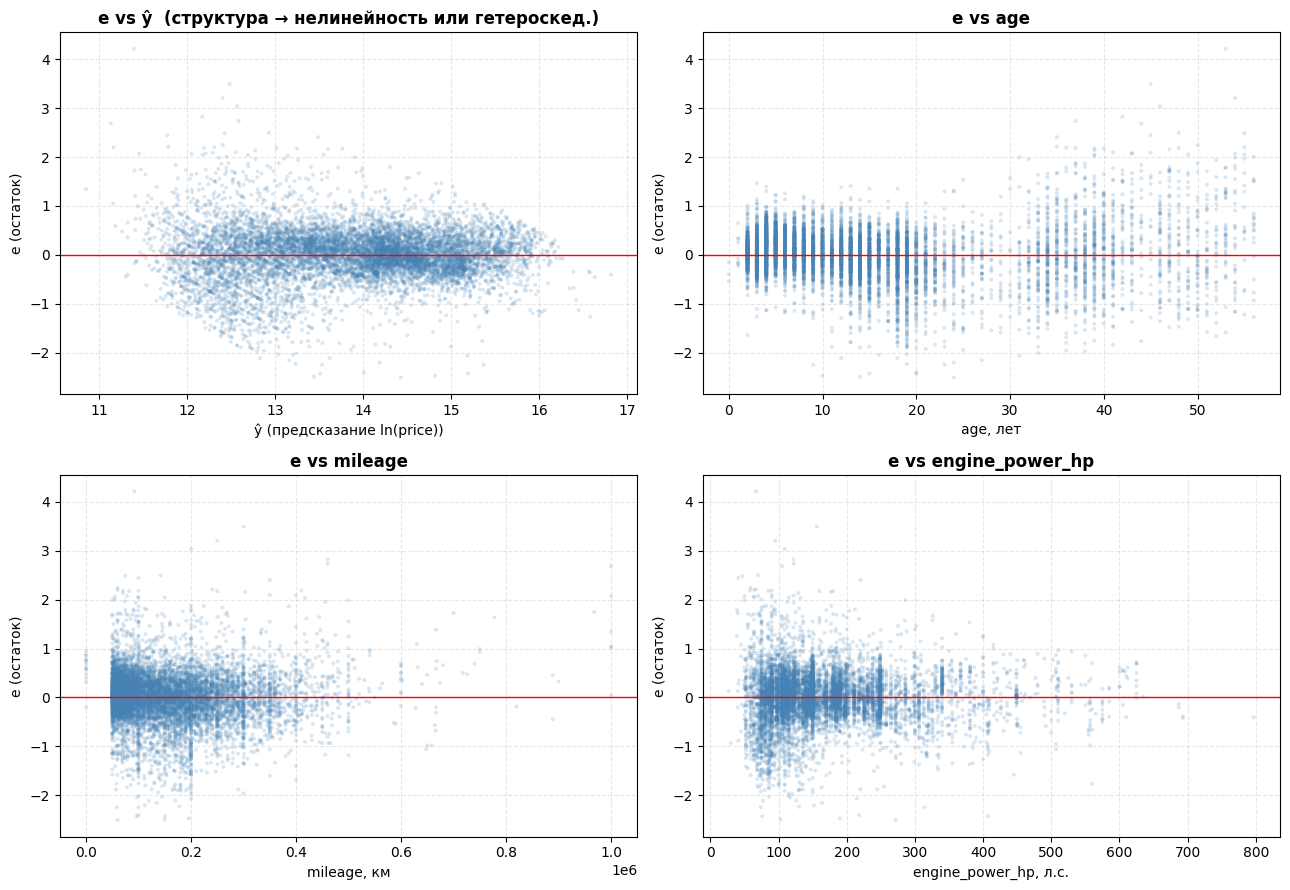

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0,0].scatter(fitted, raw_resid, alpha=0.2, s=8, color='steelblue', edgecolors='none')
axes[0,0].axhline(0, color='red', lw=1)
axes[0,0].set_xlabel('ŷ (предсказание ln(price))')
axes[0,0].set_ylabel('e (остаток)')
axes[0,0].set_title('e vs ŷ  (структура → нелинейность или гетероскед.)')

for ax, col, xlabel in [
    (axes[0,1], 'age',             'age, лет'),
    (axes[1,0], 'mileage',         'mileage, км'),
    (axes[1,1], 'engine_power_hp', 'engine_power_hp, л.с.')]:
    ax.scatter(df_train[col].values, raw_resid, alpha=0.2, s=8,
               color='steelblue', edgecolors='none')
    ax.axhline(0, color='red', lw=1)
    ax.set_xlabel(xlabel); ax.set_ylabel('e (остаток)')
    ax.set_title(f'e vs {col}')
plt.tight_layout(); plt.show()


## 4. Гомоскедастичность (конспект §3.4)

**H₀** (для BP и White): дисперсия остатков не зависит от предикторов, `D[ε_i] = σ² = const`.
**H₀** (для Goldfeld–Quandt): дисперсия одинакова в крайних группах, `σ²_I = σ²_III`.


In [6]:
# Breusch–Pagan: e²_i ~ X (линейная модель дисперсии)
bp_stat, bp_pval, _, _ = het_breuschpagan(m_min.resid, X_min_c)

# White (вручную через helpers.white_test — sm.het_white падает из-за dummy:
# x² = x для бинарных переменных → коллинеарность в вспомогательной регрессии)
num_cols_in_min = [c for c in KEEP if c in X_min_c.columns]
w_stat, w_pval, w_df, w_r2 = white_test(m_min.resid, X_min_c, num_cols=num_cols_in_min)
print(f'White: LM={w_stat:.1f}  p={w_pval:.3g}  df={w_df}  R²_aux={w_r2:.4f}')

# Goldfeld–Quandt: сортируем по age, разбиваем на 3 группы, сравниваем дисперсии крайних
order_idx = np.argsort(df_train['age'].values)
gq_stat, gq_pval, _ = het_goldfeldquandt(
    y[order_idx], X_min_c.values[order_idx], alternative='two-sided')

tests_hetero = pd.DataFrame([
    format_test_row('Breusch–Pagan', 'D[ε]=σ² const', 'LM', bp_stat, bp_pval),
    format_test_row(f'White (вручную, df={w_df})',
                    'D[ε]=σ² + нет (x², x_i·x_j) эффектов',
                    'LM', w_stat, w_pval),
    format_test_row('Goldfeld–Quandt (по age)',
                    'σ²_I=σ²_III (равенство дисперсий в крайних группах)',
                    'F', gq_stat, gq_pval),
])
tests_hetero


White: LM=1876.0  p=1.21e-304  df=134  R²_aux=0.1979


,тест,H₀,LM,p-value,α=0.05,F
0,Breusch–Pagan,D[ε]=σ² const,1362.1429,1.28e-268,отвергаем H₀,NaN
1,"White (вручную, df=134)","D[ε]=σ² + нет (x², x_i·x_j) эффектов",1876.0438,1.21e-304,отвергаем H₀,NaN
2,Goldfeld–Quandt (по age),σ²_I=σ²_III (равенство дисперсий в крайних гру...,NaN,0,отвергаем H₀,4.485


## 5. Автокорреляция (конспект §3.5)

**Durbin–Watson**: тест на автокорреляцию остатков первого порядка.
**H₀**: `Cov(ε_i, ε_{i−1}) = 0` (нет автокорреляции, DW ≈ 2).


In [7]:
dw_stat = durbin_watson(m_min.resid)
# DW не имеет p-value напрямую (зависит от X), но интерпретация по правилу:
# 1.5 < DW < 2.5 — норма; <1.5 — положительная автокорреляция; >2.5 — отрицательная
if 1.5 < dw_stat < 2.5:
    dw_decision = 'не отвергаем H₀ (DW в норме)'
elif dw_stat < 1.5:
    dw_decision = 'отвергаем H₀ (положительная автокорреляция)'
else:
    dw_decision = 'отвергаем H₀ (отрицательная автокорреляция)'

print(f'Durbin–Watson statistic = {dw_stat:.3f}')
print(f'Правило: 1.5 < DW < 2.5 → нет автокорреляции')
print(f'Вердикт: {dw_decision}')


Durbin–Watson statistic = 2.012
Правило: 1.5 < DW < 2.5 → нет автокорреляции
Вердикт: не отвергаем H₀ (DW в норме)


## 6. Линейность формы (RESET-тест Рамсея, конспект §3.6)

**H₀**: модель имеет правильную функциональную форму (нет пропущенных степеней предикторов).

Вспомогательная регрессия добавляет `ŷ²` и `ŷ³`. Если эти коэффициенты значимы — нелинейность не учтена.


In [8]:
reset_2 = linear_reset(m_min, power=2, use_f=True)
reset_3 = linear_reset(m_min, power=3, use_f=True)

tests_lin = pd.DataFrame([
    format_test_row('RESET power=2', 'форма линейна (нет ŷ²)',
                    'F', reset_2.fvalue, reset_2.pvalue),
    format_test_row('RESET power=2,3', 'форма линейна (нет ŷ², ŷ³)',
                    'F', reset_3.fvalue, reset_3.pvalue),
])
tests_lin


,тест,H₀,F,p-value,α=0.05
0,RESET power=2,форма линейна (нет ŷ²),0.0021,0.964,не отвергаем H₀
1,"RESET power=2,3","форма линейна (нет ŷ², ŷ³)",21.2055,6.47e-10,отвергаем H₀


## 7. Сводная таблица всех тестов


In [9]:
all_tests = pd.concat([tests_normality, tests_hetero, tests_lin], ignore_index=True)
all_tests


,тест,H₀,JB,p-value,α=0.05,W,LM,F
0,Jarque–Bera,"ε ~ N(0,σ²)",4621.5746,0,отвергаем H₀,NaN,NaN,NaN
1,Shapiro–Wilk (n=5000),"ε ~ N(0,σ²)",NaN,1.29e-37,отвергаем H₀,0.9521,NaN,NaN
2,Breusch–Pagan,D[ε]=σ² const,NaN,1.28e-268,отвергаем H₀,NaN,1362.1429,NaN
3,"White (вручную, df=134)","D[ε]=σ² + нет (x², x_i·x_j) эффектов",NaN,1.21e-304,отвергаем H₀,NaN,1876.0438,NaN
4,Goldfeld–Quandt (по age),σ²_I=σ²_III (равенство дисперсий в крайних гру...,NaN,0,отвергаем H₀,NaN,NaN,4.4850
5,RESET power=2,форма линейна (нет ŷ²),NaN,0.964,не отвергаем H₀,NaN,NaN,0.0021
6,"RESET power=2,3","форма линейна (нет ŷ², ŷ³)",NaN,6.47e-10,отвергаем H₀,NaN,NaN,21.2055


## 8. Вердикт по диагностике и гипотезы для улучшения

| Предпосылка | Результат | Действие |
|---|---|---|
| **Нормальность** | формально отвергнута (n=9.5k), но skew≈0, kurt≈5 — приемлемо | Box-Cox опционально (блок 8) |
| **Гомоскедастичность** | **отвергнута** (BP p≈10⁻²⁹⁵) | **Гипотеза 1**: применить WLS (блок 6) |
| **Автокорреляция** | DW ≈ 2 — нет | OK |
| **Линейность** | **отвергнута** (RESET p≈10⁻³²) | **Гипотеза 2**: добавить нелинейности (блок 5) |
| **Мультиколлинеарность** | max VIF ≈ 33 у `age` (artificial) | **Гипотеза 3**: центрирование (блок 5) |

**План улучшений**:
1. **Блок 5 — Feature Engineering**: ratio-признаки (`hp_per_kg`, `hp_per_liter`), центрирование `age`/`mileage`, новые нелинейности (`mileage²`, `engine_volume × age`).
2. **Блок 6 — WLS**: если гетероскедастичность останется после FE.
3. **Блок 7 — Сегментация**: если и WLS не убирает гетероскед.
